In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.mnist.load_data()
X_train.shape

(60000, 28, 28)

In [3]:
X_test.shape  # Check the shape of the test set

(10000, 28, 28)

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

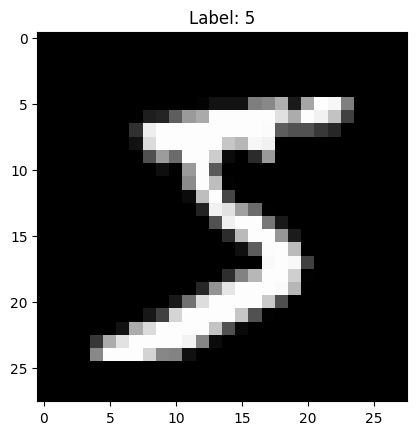

In [5]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [6]:
cnn = models.Sequential([
    # 1st block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # 2nd block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\phane\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [8]:
history = cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9074 - loss: 0.2928 - val_accuracy: 0.9739 - val_loss: 0.0876
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9718 - loss: 0.1000 - val_accuracy: 0.9777 - val_loss: 0.0756
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9795 - loss: 0.0740 - val_accuracy: 0.9835 - val_loss: 0.0571
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9838 - loss: 0.0573 - val_accuracy: 0.9843 - val_loss: 0.0604
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9872 - loss: 0.0464 - val_accuracy: 0.9869 - val_loss: 0.0491
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9884 - loss: 0.0416 - val_accuracy: 0.9839 - val_loss: 0.0663
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9905 - loss: 0.0322 - val_accuracy: 0.9878 - val_loss: 0.0495
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9910 - lo

In [9]:
import random

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


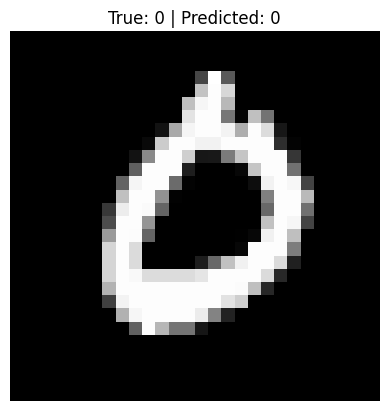

In [10]:
def predict_random_image(model, X_data, y_data):
    # Pick a random index
    index = random.randint(0, len(X_data) - 1)
    
    # Select image & true label
    img = X_data[index]
    true_label = y_data[index]
    
    # Predict
    pred = model.predict(img.reshape(1, 28, 28, 1))
    pred_label = np.argmax(pred)
    
    # Plot
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_label} | Predicted: {pred_label}")
    plt.axis("off")
    plt.show()

predict_random_image(cnn, X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
 [[ 972    1    1    0    0    2    2    1    1    0]
 [   0 1129    0    1    0    0    2    2    1    0]
 [   4    0  996    8    2    0    4   18    0    0]
 [   2    2    1  998    0    2    0    4    1    0]
 [   0    0    0    0  974    0    2    0    2    4]
 [   1    0    0    7    0  871    1    1    8    3]
 [   1    2    0    0    2    1  948    0    4    0]
 [   1    3    3    1    0    1    0 1019    0    0]
 [   0    0    2    4    2    0    0    1  959    6]
 [   1    0    0    1    4    2    0    4    5  992]]


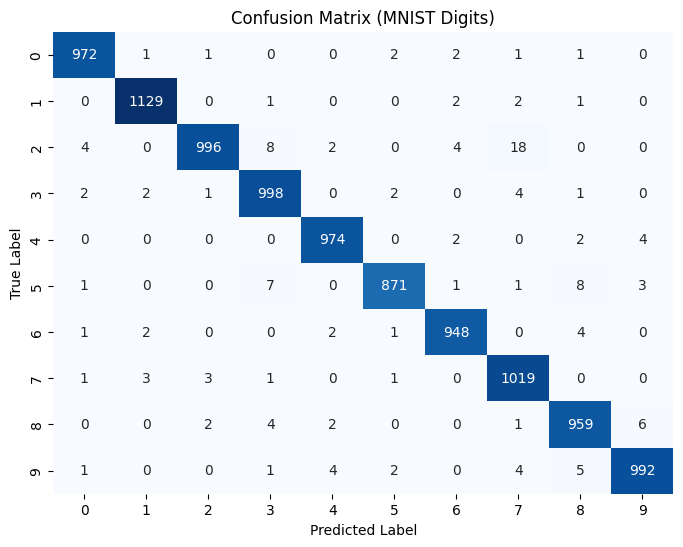


Per-Class TP / FP / FN / TN:
Class 0: TP=972, FP=10, FN=8, TN=9010
Class 1: TP=1129, FP=8, FN=6, TN=8857
Class 2: TP=996, FP=7, FN=36, TN=8961
Class 3: TP=998, FP=22, FN=12, TN=8968
Class 4: TP=974, FP=10, FN=8, TN=9008
Class 5: TP=871, FP=8, FN=21, TN=9100
Class 6: TP=948, FP=11, FN=10, TN=9031
Class 7: TP=1019, FP=31, FN=9, TN=8941
Class 8: TP=959, FP=22, FN=15, TN=9004
Class 9: TP=992, FP=13, FN=17, TN=8978

Classification Report:

              precision    recall  f1-score   support

           0     0.9898    0.9918    0.9908       980
           1     0.9930    0.9947    0.9938      1135
           2     0.9930    0.9651    0.9789      1032
           3     0.9784    0.9881    0.9833      1010
           4     0.9898    0.9919    0.9908       982
           5     0.9909    0.9765    0.9836       892
           6     0.9885    0.9896    0.9890       958
           7     0.9705    0.9912    0.9808      1028
           8     0.9776    0.9846    0.9811       974
           9     0.

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)   # predicted class indices
y_true = y_test.astype(int)                  # true labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.title("Confusion Matrix (MNIST Digits)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Calculate TP, FP, FN, TN for each class
print("\nPer-Class TP / FP / FN / TN:")
for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    print(f"Class {i}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, digits=4))
